In [97]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

def plot_tSNR_forimage(fname,mask_fname,centre):
# Load the 4D EPI image
    epi_img = nib.load(fname)
    epi_data = epi_img.get_fdata()

    mask_img = nib.load(mask_fname)
    mask_data = mask_img.get_fdata()

    # Choose a slice, for example, the 10th slice in the z-dimension
    z_slice = 30
    epi_slice = epi_data[:, :, z_slice, :]

    # Calculate temporal mean and standard deviation
    temporal_mean = np.mean(epi_slice, axis=-1)
    temporal_std = np.std(epi_slice, axis=-1)

    # Calculate tSNR for the slice: mean / standard deviation
    tsnr = temporal_mean / (temporal_std + 1e-8)  # added small value to avoid division by zero

    # Plot the slice with tSNR values
    plt.imshow(tsnr, cmap='jet',    vmin=0,vmax=30,)
    plt.colorbar()
    plt.title(f'tSNR of slice {z_slice} {centre}')
    plt.show()

    # Calculate tSNR for the entire 4D image
    tsnr_volume = np.mean(epi_data[mask_data>0.5,:], axis=-1) / (np.std(epi_data[mask_data>0.5,:], axis=-1) + 1e-8)
    tsnr_volume = tsnr_volume.ravel()
    # Plot histogram of tSNR for the entire image
    plt.hist(tsnr_volume[tsnr_volume<100], bins=100, color='gray')
    plt.xlim([0,80])

    plt.xlabel('tSNR')
    plt.ylabel('Number of voxels')
    plt.title(f'Histogram of GM tSNR values {centre}')
    plt.grid(True)
    plt.show()

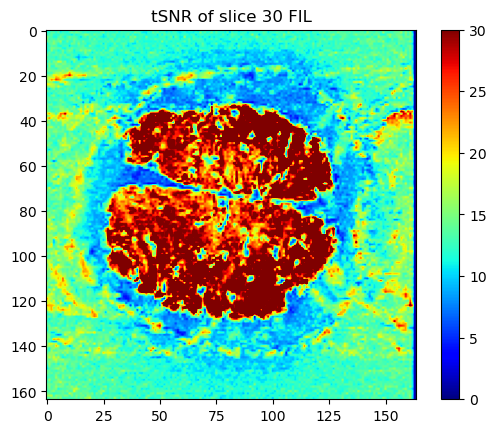

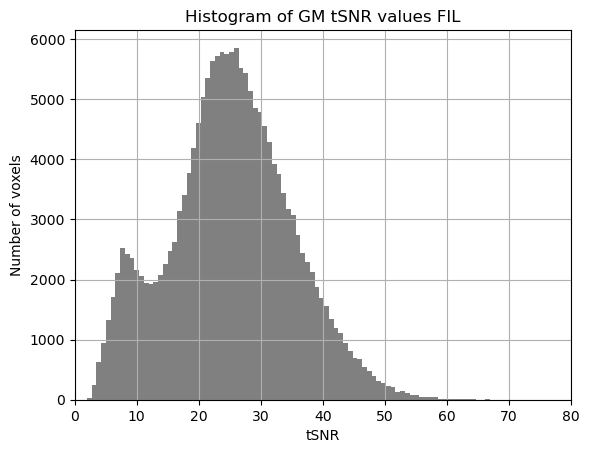

In [98]:

plot_tSNR_forimage('../../pilot_data_for_Roni/run1_mcf.nii.gz','../../pilot_data_for_Roni/brainmask_pve_1_inverse.nii.gz','FIL')

# plot_tSNR_forimage('../../pilot_data_for_Roni/run2.nii.gz','FIL')
# plot_tSNR_forimage('../../pilot_data_for_Roni/run3.nii.gz','FIL')
# plot_tSNR_forimage('../../pilot_data_for_Roni/run4_1mm.nii.gz','FIL_1mm')

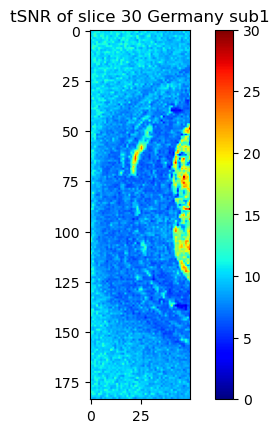

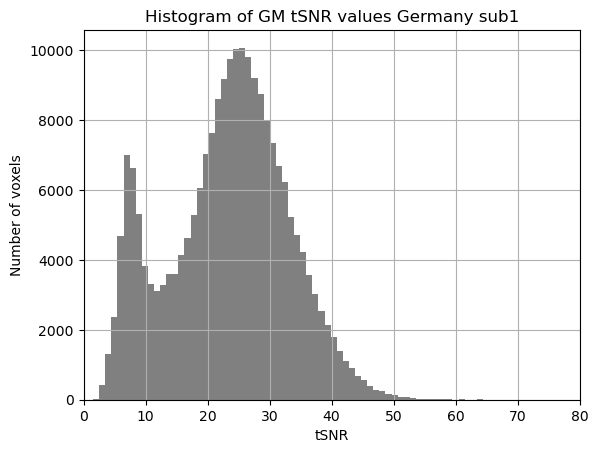

In [99]:
plot_tSNR_forimage('../../hanealt_data/subj-01_color-task_sess-01_run-01_bold_mcf.nii.gz','../../hanealt_data/Germany_brainmask_pve_1_inverse.nii.gz','Germany sub1')
# plot_tSNR_forimage('../../hanealt_data/subj-01_color-task_sess-01_run-02_bold.nii.gz','Germany')
# plot_tSNR_forimage('../../hanealt_data/subj-01_color-task_sess-01_run-03_bold.nii.gz','Germany')


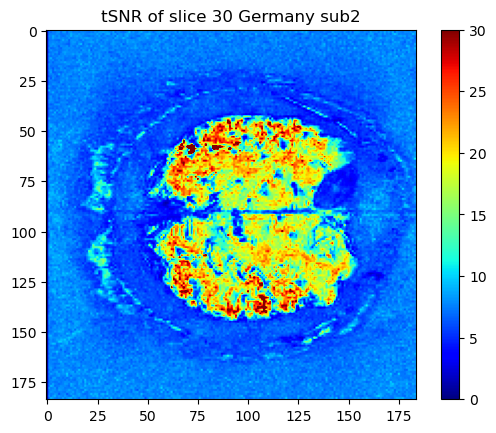

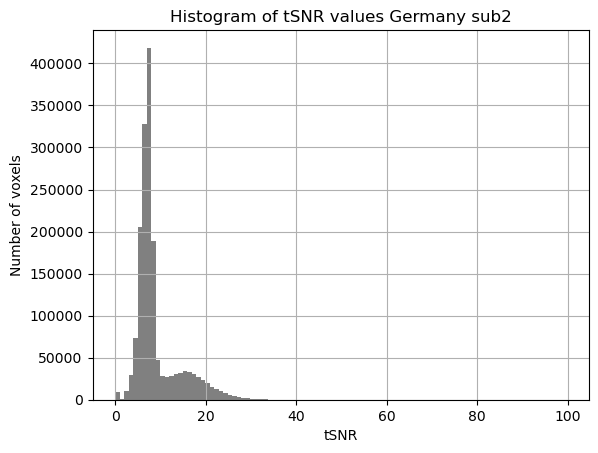

In [81]:
plot_tSNR_forimage('../../hanealt_data/subj-02_color-task_sess-01_run-01_bold.nii.gz','Germany sub2')
